# Librerias

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Carga del set de datos

In [28]:
df = pd.read_csv("../data/processed/german_credit.csv")
print(df.shape)
df.head()

(1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## Verificamos si hay valores nulos

In [29]:
df.isnull().sum()


checking_status        0
duration               0
credit_history         0
purpose                0
credit_amount          0
savings_status         0
employment             0
installment_rate       0
personal_status        0
other_parties          0
residence_since        0
property_magnitude     0
age                    0
other_payment_plans    0
housing                0
existing_credits       0
job                    0
num_dependents         0
own_telephone          0
foreign_worker         0
class                  0
dtype: int64

## Información básica

In [38]:
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nPrimeras 5 filas:")
display(df.head())

print("\nÚltimas 5 filas:")
display(df.tail())

print("\nInformación de tipos de datos:")
print(df.info())

print("\nNombres de columnas:")
print(df.columns.tolist())

Dimensiones: 1000 filas, 21 columnas
Tamaño en memoria: 0.71 MB

Primeras 5 filas:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2



Últimas 5 filas:


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2
999,A12,45,A34,A41,4576,A62,A71,3,A93,A101,...,A123,27,A143,A152,1,A173,1,A191,A201,1



Información de tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   checking_status      1000 non-null   str  
 1   duration             1000 non-null   int64
 2   credit_history       1000 non-null   str  
 3   purpose              1000 non-null   str  
 4   credit_amount        1000 non-null   int64
 5   savings_status       1000 non-null   str  
 6   employment           1000 non-null   str  
 7   installment_rate     1000 non-null   int64
 8   personal_status      1000 non-null   str  
 9   other_parties        1000 non-null   str  
 10  residence_since      1000 non-null   int64
 11  property_magnitude   1000 non-null   str  
 12  age                  1000 non-null   int64
 13  other_payment_plans  1000 non-null   str  
 14  housing              1000 non-null   str  
 15  existing_credits     1000 non-null   int64
 16  job 

## Estadísticas para variables numéricas


In [39]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    print("VARIABLES NUMÉRICAS:")
    display(df[numeric_cols].describe())

    # Estadísticas adicionales
    print("\nEstadísticas adicionales:")
    stats_df = pd.DataFrame({
        'Media': df[numeric_cols].mean(),
        'Mediana': df[numeric_cols].median(),
        'Moda': df[numeric_cols].mode().iloc[0] if not df[numeric_cols].empty else np.nan,
        'Varianza': df[numeric_cols].var(),
        'Desv_Std': df[numeric_cols].std(),
        'Asimetría': df[numeric_cols].skew(),
        'Curtosis': df[numeric_cols].kurtosis(),
        'Min': df[numeric_cols].min(),
        'Max': df[numeric_cols].max(),
        'Rango': df[numeric_cols].max() - df[numeric_cols].min()
    }).round(3)
    display(stats_df)

# Estadísticas para variables categóricas
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
if len(categorical_cols) > 0:
    print("\nVARIABLES CATEGÓRICAS:")
    for col in categorical_cols:
        print(f"\n{col.upper()}:")
        print(f"Valores únicos: {df[col].nunique()}")
        print("Distribución de frecuencias:")
        print(df[col].value_counts())
        print("Distribución de porcentajes:")
        print(df[col].value_counts(normalize=True) * 100)

VARIABLES NUMÉRICAS:


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000



Estadísticas adicionales:


,Media,Mediana,Moda,Varianza,Desv_Std,Asimetría,Curtosis,Min,Max,Rango
duration,20.903,18.0,24.0,145.415,12.059,1.094,0.920,4,72,68
credit_amount,3271.258,2319.5,1258.0,7967843.471,2822.737,1.950,4.293,250,18424,18174
installment_rate,2.973,3.0,4.0,1.252,1.119,-0.531,-1.210,1,4,3
residence_since,2.845,3.0,4.0,1.218,1.104,-0.273,-1.381,1,4,3
age,35.546,33.0,27.0,129.401,11.375,1.021,0.596,19,75,56
existing_credits,1.407,1.0,1.0,0.334,0.578,1.273,1.604,1,4,3
num_dependents,1.155,1.0,1.0,0.131,0.362,1.909,1.649,1,2,1
class,1.300,1.0,1.0,0.210,0.458,0.874,-1.238,1,2,1



VARIABLES CATEGÓRICAS:

CHECKING_STATUS:
Valores únicos: 4
Distribución de frecuencias:
checking_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64
Distribución de porcentajes:
checking_status
A14    39.4
A11    27.4
A12    26.9
A13     6.3
Name: proportion, dtype: float64

CREDIT_HISTORY:
Valores únicos: 5
Distribución de frecuencias:
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64
Distribución de porcentajes:
credit_history
A32    53.0
A34    29.3
A33     8.8
A31     4.9
A30     4.0
Name: proportion, dtype: float64

PURPOSE:
Valores únicos: 10
Distribución de frecuencias:
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64
Distribución de porcentajes:
purpose
A43     28.0
A40     23.4
A42     18.1
A41     10.3
A49      9.7
A46      5.0
A45      2.2
A44      1.2
A410     1.2
A48      0.9
Name: proportion, dtype

C:\Users\johel\AppData\Local\Temp\ipykernel_23280\2886863125.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns


## Visualización de distribuciones para variables numéricas


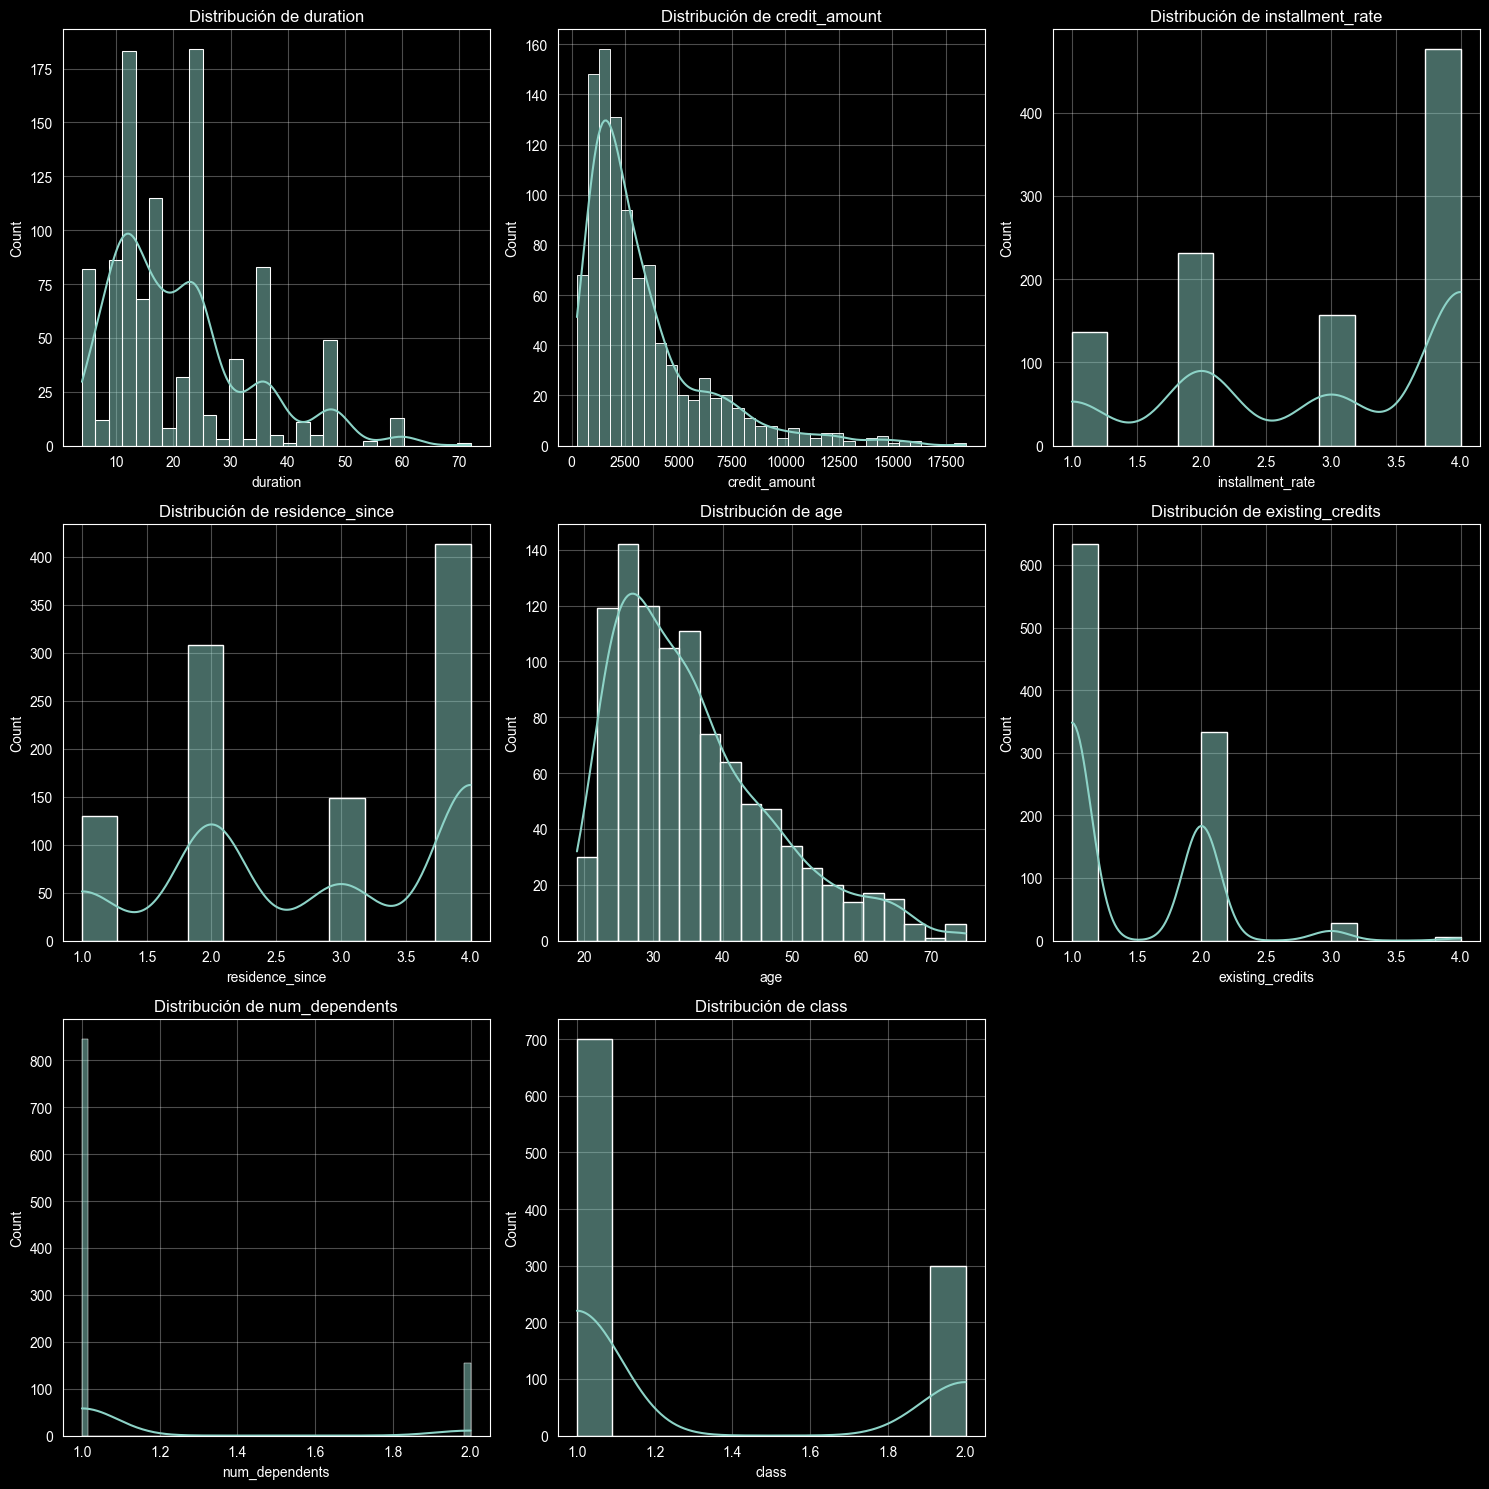

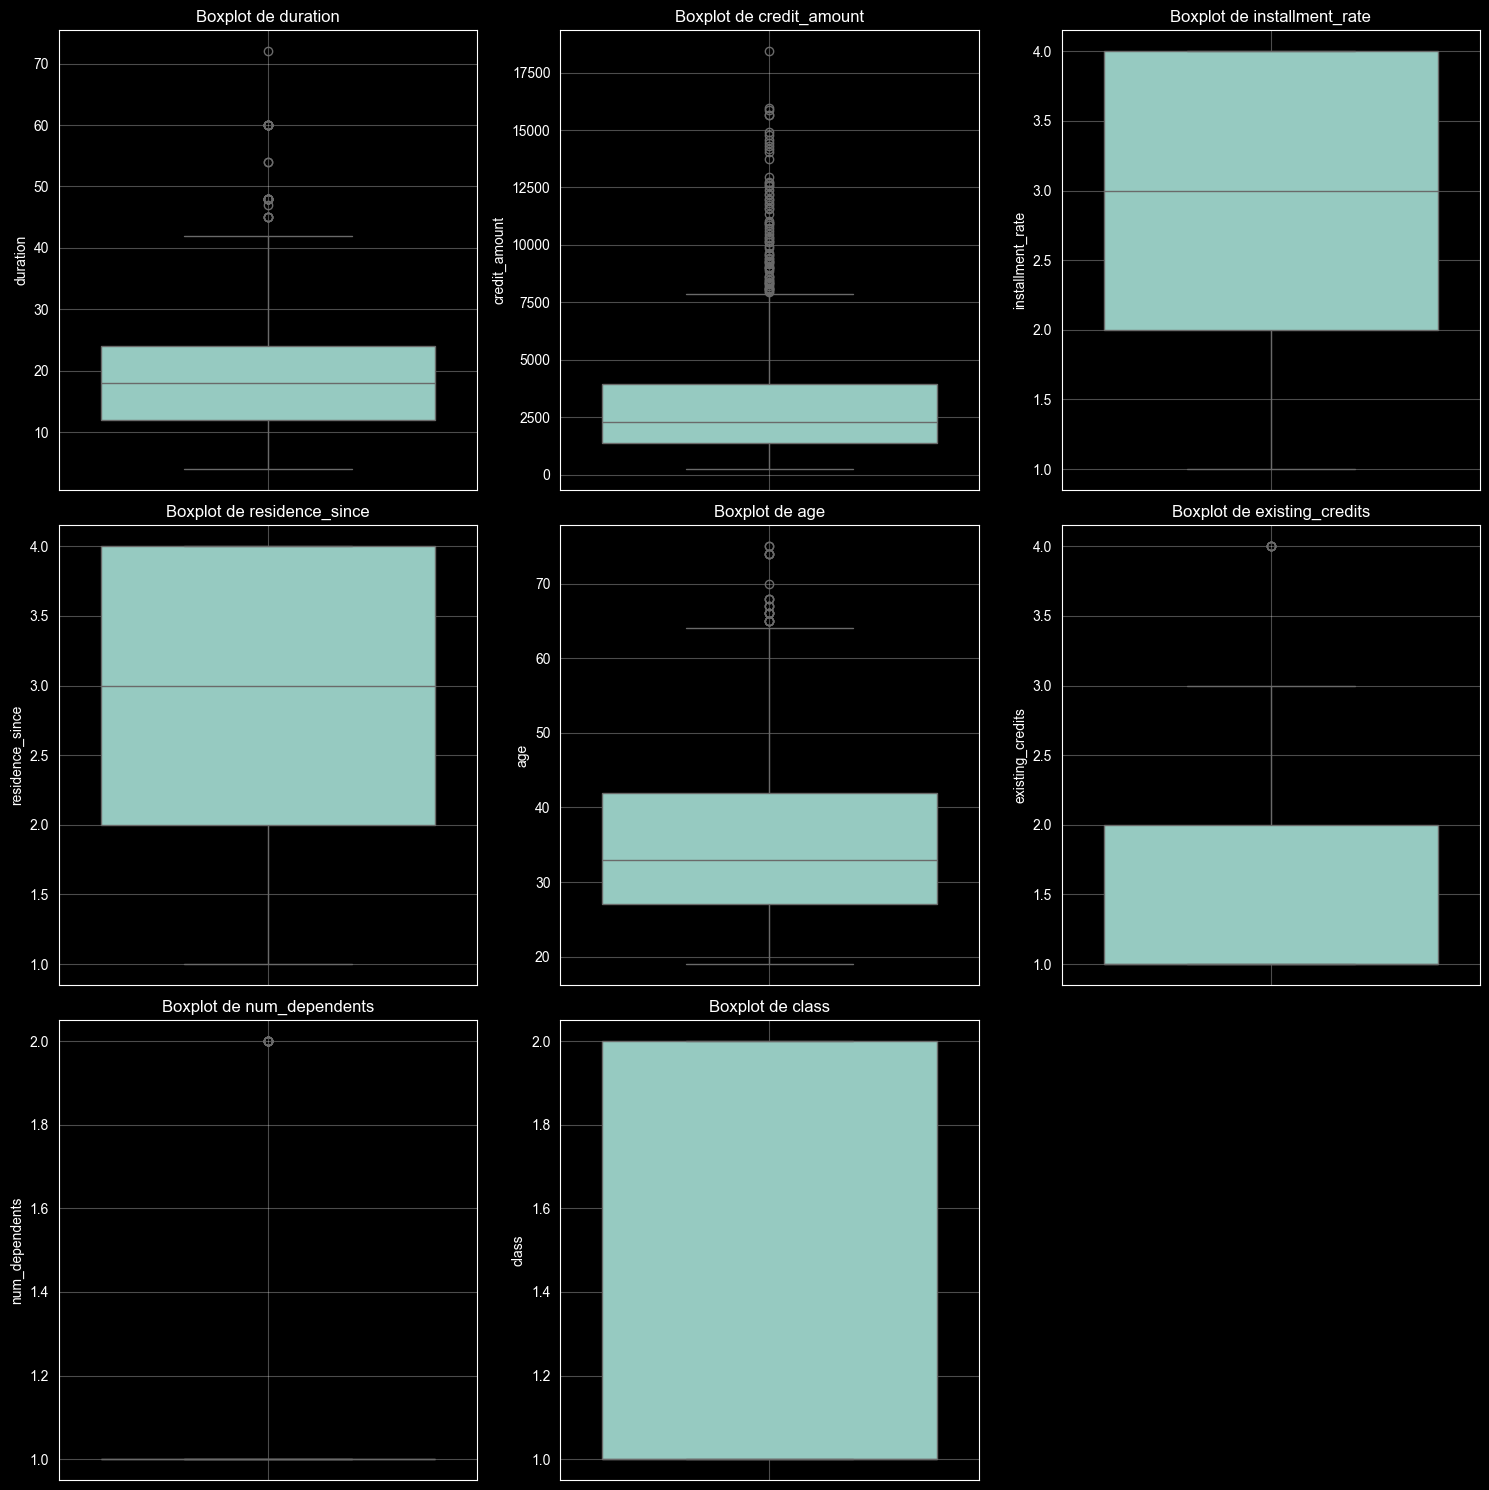

In [41]:
if len(numeric_cols) > 0:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            # Histograma con curva de densidad
            sns.histplot(data=df, x=col, kde=True, ax=axes[i])
            axes[i].set_title(f'Distribución de {col}')
            axes[i].grid(True, alpha=0.3)

    # Ocultar ejes no utilizados
    for i in range(len(numeric_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()

# Boxplots para detectar outliers
if len(numeric_cols) > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        if i < len(axes):
            sns.boxplot(data=df, y=col, ax=axes[i])
            axes[i].set_title(f'Boxplot de {col}')
            axes[i].grid(True, alpha=0.3)

    # Ocultar ejes no utilizados
    for i in range(len(numeric_cols), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


## Correlaciones

Matriz de correlación:


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,class
duration,1.000,0.625,0.075,0.034,-0.036,-0.011,-0.024,0.215
credit_amount,0.625,1.000,-0.271,0.029,0.033,0.021,0.017,0.155
installment_rate,0.075,-0.271,1.000,0.049,0.058,0.022,-0.071,0.072
residence_since,0.034,0.029,0.049,1.000,0.266,0.090,0.043,0.003
age,-0.036,0.033,0.058,0.266,1.000,0.149,0.118,-0.091
existing_credits,-0.011,0.021,0.022,0.090,0.149,1.000,0.110,-0.046
num_dependents,-0.024,0.017,-0.071,0.043,0.118,0.110,1.000,-0.003
class,0.215,0.155,0.072,0.003,-0.091,-0.046,-0.003,1.000


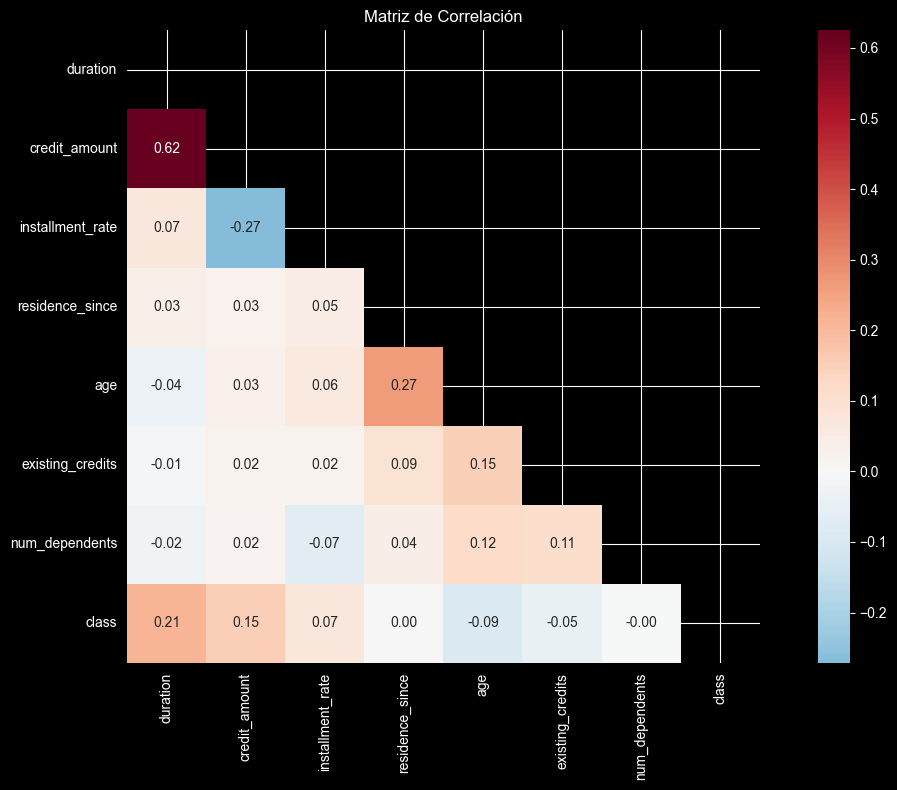

In [44]:
if len(numeric_cols) > 1:
    # Matriz de correlación
    correlation_matrix = df[numeric_cols].corr()

    print("Matriz de correlación:")
    display(correlation_matrix.round(3))

    # Heatmap de correlaciones
    plt.figure(figsize=(12, 8))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix,
                annot=True,
                cmap='RdBu_r',
                center=0,
                mask=mask,
                square=True,
                fmt='.2f')
    plt.title('Matriz de Correlación')
    plt.tight_layout()
    plt.show()

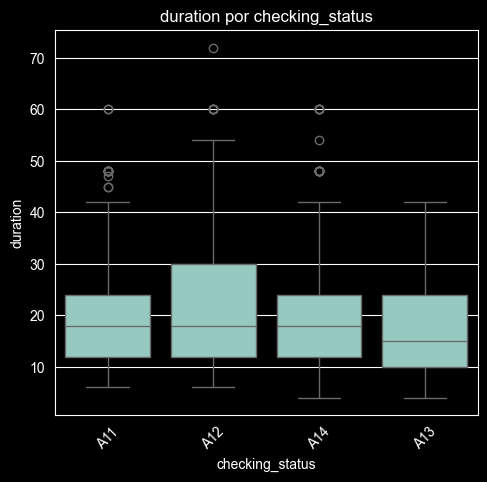

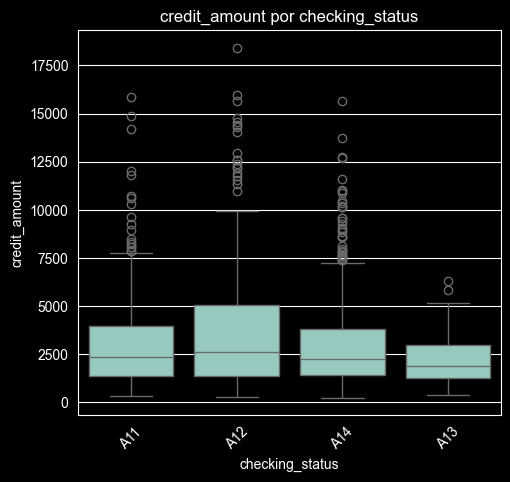

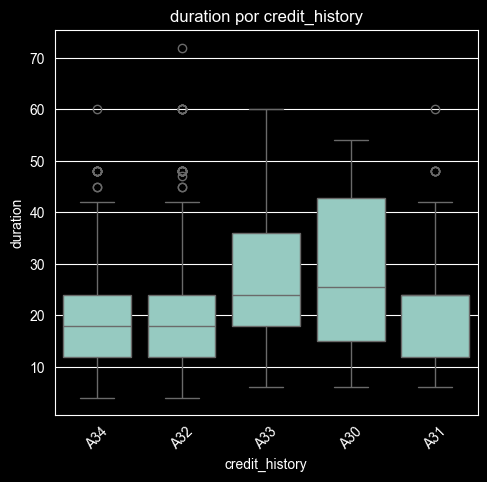

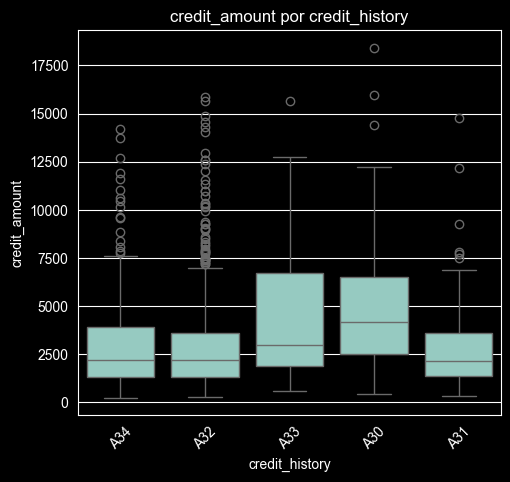

In [47]:
# Análisis entre variables categóricas y numéricas
if len(categorical_cols) > 0 and len(numeric_cols) > 0:
    for cat_col in categorical_cols[:2]:  # Limitar a las primeras 2 categóricas
        for num_col in numeric_cols[:2]:  # Limitar a las primeras 2 numéricas
            plt.figure(figsize=(12, 5))

            # Boxplot
            plt.subplot(1, 2, 1)
            sns.boxplot(data=df, x=cat_col, y=num_col)
            plt.title(f'{num_col} por {cat_col}')
            plt.xticks(rotation=45)


## Target

In [52]:
column_names = [
    'status_checking', 'duration_months', 'credit_history', 'purpose',
    'credit_amount', 'savings_account', 'employment_since', 'investment_rate',
    'status_sex', 'other_debtors', 'residence_since', 'property',
    'age', 'other_installments', 'housing', 'existing_credits',
    'job', 'people_liable', 'telephone', 'foreign_worker', 'target'
]

raw_data_path = "../data/raw/german.data"

df = pd.read_csv(raw_data_path, sep=r'\s+', names=column_names, header=None)

# El dataset original usa 1 para buen crédito y 2 para mal crédito.
# Lo transformamos a 0 (Buen Crédito) y 1 (Mal Crédito).
df['target'] = df['target'].map({1: 0, 2: 1})

print(f"Dimensiones del dataset cargado: {df.shape}")
df.head()

Dimensiones del dataset cargado: (1000, 21)


,status_checking,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,investment_rate,status_sex,other_debtors,...,property,age,other_installments,housing,existing_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [51]:
print(df.columns.tolist())

['status_checking', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_since', 'investment_rate', 'status_sex', 'other_debtors', 'residence_since', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'people_liable', 'telephone', 'foreign_worker', 'target']
